# Regime-Switching Macro Model — FRED Data

Ricky Li

Downloads four US macroeconomic observables from FRED, aligns them to a
clean quarterly DataFrame, then runs the full `regime_change_macro.py`
pipeline: **simulate → filter → smoother → forecast**.

| Observable | FRED series | Transformation |
|---|---|---|
| Real GDP growth | `GDPC1` (quarterly) | 400 × log(GDP_t / GDP_{t−1}) |
| Unemployment rate | `UNRATE` (monthly → quarterly) | mean |
| Inflation | `CPIAUCSL` (monthly → quarterly) | 400 × log(CPI_t / CPI_{t−1}) |
| Short-term interest rate | `FEDFUNDS` (monthly → quarterly) | mean |

In [27]:
# !pip install -q fredapi

import sys, os
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from fredapi import Fred

from regime_change_macro import (
    ModelDims, MacroParams, RegimeMacroModel,
    simulate, kim_filter, kim_smoother, forecast,
    ParamPacker, negative_loglik, row_softmax,
)

FRED_API_KEY = "196e4e409fdb4918afa9069fe5b598e0"  # replace with your own key
fred = Fred(api_key=FRED_API_KEY)

## 1  Download Data from FRED

In [28]:
gdp_raw  = fred.get_series("GDPC1")      # Real GDP, quarterly
unrate_m = fred.get_series("UNRATE")     # Unemployment, monthly
cpi_m    = fred.get_series("CPIAUCSL")   # CPI, monthly
ffr_m    = fred.get_series("FEDFUNDS")   # Fed Funds Rate, monthly

print(f"GDPC1   : {gdp_raw.index[0].date()} – {gdp_raw.index[-1].date()}")
print(f"UNRATE  : {unrate_m.index[0].date()} – {unrate_m.index[-1].date()}")
print(f"CPIAUCSL: {cpi_m.index[0].date()} – {cpi_m.index[-1].date()}")
print(f"FEDFUNDS: {ffr_m.index[0].date()} – {ffr_m.index[-1].date()}")

GDPC1   : 1947-01-01 – 2026-01-01
UNRATE  : 1948-01-01 – 2026-04-01
CPIAUCSL: 1947-01-01 – 2026-04-01
FEDFUNDS: 1954-07-01 – 2026-04-01


## 2  Align to Quarterly Frequency and Keep Complete Data

All growth/rate series are expressed as **annualised percent per year** so
that the model's Taylor-rule equation is dimensionally consistent.

In [29]:
# Real GDP growth: 400 × log-difference (annualised quarterly growth rate)
# FRED's GDPC1 already has start-of-quarter dates (Jan 1, Apr 1, …) matching QS resample below
gdp_growth = 400 * np.log(gdp_raw / gdp_raw.shift(1))
gdp_growth = gdp_growth.dropna()

# Unemployment: monthly → quarterly mean (already in %)
unrate_q = unrate_m.resample("QS").mean()

# CPI: monthly → quarterly mean → annualised inflation
cpi_q  = cpi_m.resample("QS").mean()
inf_q  = (400 * np.log(cpi_q / cpi_q.shift(1))).dropna()

# Fed Funds Rate: monthly → quarterly mean (already annualised %)
ffr_q = ffr_m.resample("QS").mean()

# Merge and keep only the rows with all four series present
df = pd.DataFrame({
    "gdp_growth":   gdp_growth,
    "unemployment": unrate_q,
    "inflation":    inf_q,
    "ffr":          ffr_q,
}).dropna()

print(f"Date range: {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} quarters)")
df.head()

Date range: 1954-07-01 → 2026-01-01  (287 quarters)


,gdp_growth,unemployment,inflation,ffr
1954-07-01,4.493424,5.966667,-1.041861,1.030000
1954-10-01,7.752247,5.333333,-1.243859,0.986667
1955-01-01,11.266225,4.733333,0.547775,1.343333
1955-04-01,6.457770,4.400000,-0.547775,1.500000
1955-07-01,5.367116,4.100000,0.298879,1.940000


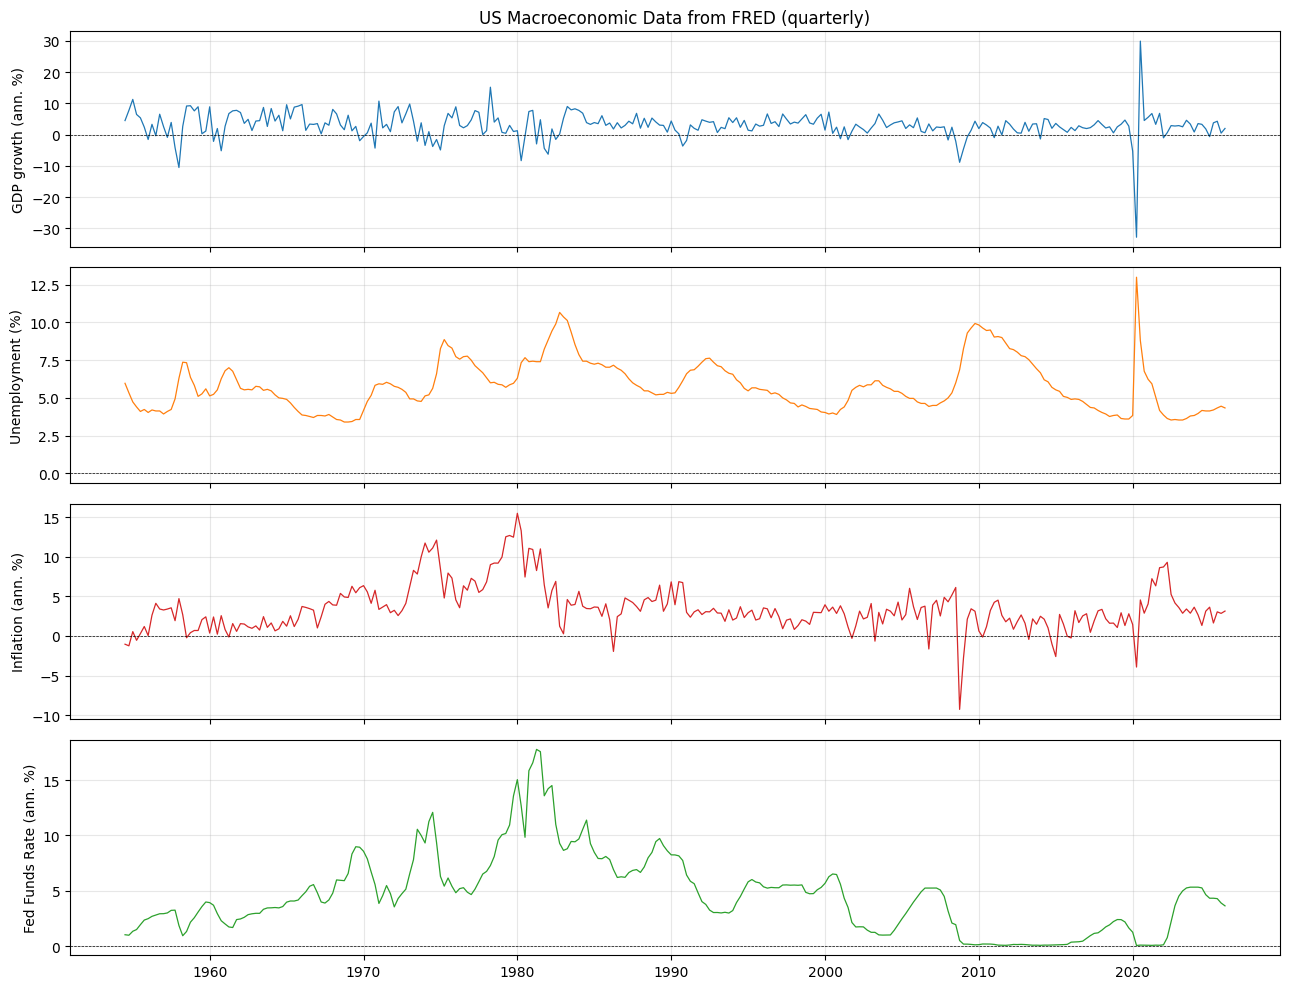

In [30]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

series_info = [
    ("gdp_growth",   "GDP growth (ann. %)",    "tab:blue"),
    ("unemployment", "Unemployment (%)",        "tab:orange"),
    ("inflation",    "Inflation (ann. %)",      "tab:red"),
    ("ffr",          "Fed Funds Rate (ann. %)", "tab:green"),
]
for ax, (col, label, color) in zip(axes, series_info):
    ax.plot(df.index, df[col], color=color, linewidth=0.9)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

axes[0].set_title("US Macroeconomic Data from FRED (quarterly)")
plt.tight_layout()

In [31]:
# pre 2022-12-31
train_df = df[df.index <= "2022-12-31"]
print(f"Training data: {train_df.index[0].date()} → {train_df.index[-1].date()}  ({len(train_df)} quarters)")

Training data: 1954-07-01 → 2022-10-01  (274 quarters)


## 3  Model Setup

We use **K = 2 regimes** (low-volatility and high-volatility) with
illustrative but economically plausible parameters.

All growth and rate parameters are in **annualised percent per year**,
consistent with the data transformation above.

In [32]:
K = 2  # regimes: 0 = low-volatility, 1 = high-volatility

dims = ModelDims(n_regimes=K, n_state=6, n_obs=4)

params = MacroParams(
    # --- Quarterly AR(1) persistence of latent state components ---
    rho_x  = 0.85,   # output gap
    rho_g  = 0.95,   # trend growth
    rho_u  = 0.97,   # natural rate of unemployment
    rho_pi = 0.95,   # expected inflation
    rho_r  = 0.85,   # neutral real interest rate

    # --- Long-run means (annualised %) ---
    g_bar  = 2.0,    # trend growth  ~2 %/yr
    u_bar  = 4.5,    # natural unemployment  ~4.5 %
    pi_bar = 2.0,    # long-run inflation  ~2 %/yr
    r_bar  = 0.75,    # neutral real rate  ~0.75 %/yr

    # --- Structural slopes ---
    lambda_r = 0.10,  # real-rate gap effect on output gap
    beta_u   = 0.40,  # Okun's law coefficient
    kappa    = 0.075,  # Phillips curve slope

    # --- Taylor rule ---
    rho_i     = 0.85,  # interest-rate smoothing
    phi_pi    = 1.50,  # inflation response
    phi_x     = 0.50,  # output gap response
    pi_target = 2.0,   # inflation target

    # --- State-shock standard deviations by regime (K × 5) ---
    #     columns: [x, g*, u*, pi^e, r*]
    state_sigmas = np.array([
        [0.30, 0.10, 0.05, 0.10, 0.15],   # regime 0: low-vol
        [2.00, 0.50, 0.30, 0.60, 1.00],   # regime 1: high-vol
    ]),

    # --- Measurement-noise std (GDP growth, unemployment, inflation, FFR) ---
    obs_sigmas = np.array([0.50, 0.15, 0.75, 0.50]),

    # --- Markov transition intercepts (diagonal-dominant → persistent regimes) ---
    trans_intercepts = np.array([[1.5, -1.5],
                                  [-0.75,  0.75]]),
)

model = RegimeMacroModel(params, dims)
print("Model created successfully.")

Model created successfully.


## 4  Simulate an Example Trajectory

We draw a synthetic path of 160 quarters (~40 years) from the model to
verify that the parameters produce plausible macro dynamics before applying
the model to real data.

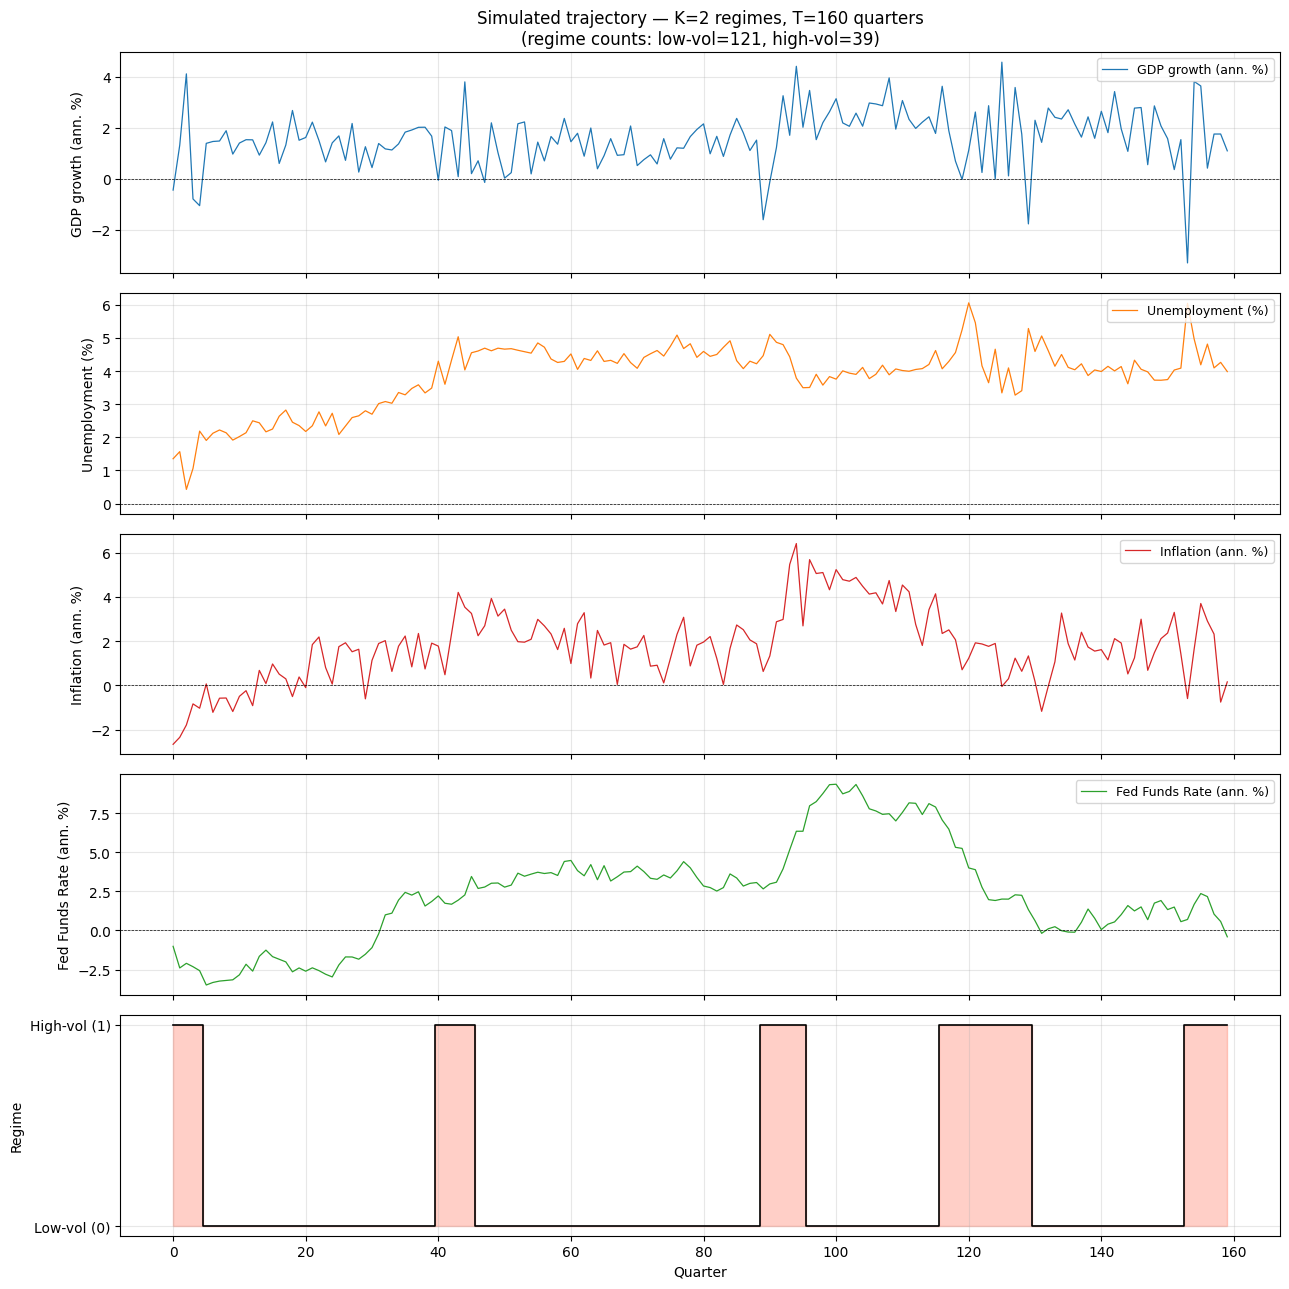

In [33]:
sim = simulate(model, T=160, seed=42)

t_idx = np.arange(len(sim.y))

fig, axes = plt.subplots(5, 1, figsize=(13, 13), sharex=True)

obs_info = [
    (0, "GDP growth (ann. %)",    "tab:blue"),
    (1, "Unemployment (%)",        "tab:orange"),
    (2, "Inflation (ann. %)",      "tab:red"),
    (3, "Fed Funds Rate (ann. %)", "tab:green"),
]
for i, (col, label, color) in enumerate(obs_info):
    axes[i].plot(t_idx, sim.y[:, col], color=color, linewidth=0.9, label=label)
    axes[i].axhline(0, color="black", linewidth=0.5, linestyle="--")
    axes[i].set_ylabel(label)
    axes[i].legend(loc="upper right", fontsize=9)
    axes[i].grid(True, alpha=0.3)

# Regime strip
axes[4].step(t_idx, sim.s, where="mid", color="black", linewidth=1.2)
axes[4].fill_between(t_idx, sim.s, step="mid", alpha=0.3, color="tomato")
axes[4].set_yticks([0, 1])
axes[4].set_yticklabels(["Low-vol (0)", "High-vol (1)"])
axes[4].set_ylabel("Regime")
axes[4].set_xlabel("Quarter")
axes[4].grid(True, alpha=0.3)

axes[0].set_title(f"Simulated trajectory — K=2 regimes, T={len(sim.y)} quarters\n"
                  f"(regime counts: low-vol={np.sum(sim.s==0)}, high-vol={np.sum(sim.s==1)})")
plt.tight_layout()

## 5  Parameter Estimation

We estimate the **18 free parameters** (regime-specific state shock stds,
observation noise stds, Markov transition intercepts) by maximum likelihood
using the Kim filter log-likelihood, holding all structural/persistence
parameters fixed at the calibrated values above.

The optimizer runs L-BFGS-B on the unconstrained vector
θ = [log σ_state (K×5), log σ_obs (4), a_trans (K×K)].
This may take a minute or two.

In [34]:
from scipy.optimize import minimize
from dataclasses import replace as dc_replace

y = train_df[["gdp_growth", "unemployment", "inflation", "ffr"]].to_numpy()


class MacroParamPacker(ParamPacker):
    """
    Concrete ParamPacker that estimates state_sigmas, obs_sigmas, and
    trans_intercepts while holding all structural/persistence parameters fixed.

    Unconstrained vector layout:
        theta = [log(state_sigmas.flat)  (K*5),
                 log(obs_sigmas)          (4),
                 trans_intercepts.flat    (K*K)]
    """

    def __init__(self, dims, fixed_params):
        super().__init__(dims)
        self.fixed = fixed_params

    def pack(self, p):
        return np.concatenate([
            np.log(p.state_sigmas.flatten()),   # K*5  log-sigmas
            np.log(p.obs_sigmas),               # 4    log-obs-sigmas
            p.trans_intercepts.flatten(),        # K*K  unconstrained
        ])

    def unpack(self, theta_raw):
        K   = self.dims.n_regimes
        idx = 0

        state_sigmas = np.exp(theta_raw[idx : idx + K * 5]).reshape(K, 5)
        idx += K * 5

        obs_sigmas = np.exp(theta_raw[idx : idx + 4])
        idx += 4

        trans_intercepts = theta_raw[idx : idx + K * K].reshape(K, K)

        return dc_replace(
            self.fixed,
            state_sigmas=state_sigmas,
            obs_sigmas=obs_sigmas,
            trans_intercepts=trans_intercepts,
        )


packer = MacroParamPacker(dims, params)
theta0 = packer.pack(params)
print(f"Optimising {len(theta0)} parameters.")

Optimising 18 parameters.


In [43]:
%%time
num_starts = 5
results = []

for i in range(num_starts):
    print(f"\nStarting optimization run {i+1}/{num_starts}...")
    x0 = theta0 + 0.1 * np.random.randn(len(theta0))  # perturb initial guess
    results.append(minimize(
        fun=negative_loglik,
        x0=x0,
        args=(packer, y),
        method="L-BFGS-B",
        options={"maxiter": 500, "disp": True},
    ))

# Check parameter estimates and log-likelihoods across runs
print("\nOptimization results across runs:")
for i, res in enumerate(results):
    print(f"Run {i+1}: log-likelihood = {-res.fun:.2f}, success={res.success}, message='{res.message}'")
    params_est = packer.unpack(res.x)
    print(f"  Estimated state_sigmas (regime 0): {params_est.state_sigmas[0]}")
    print(f"  Estimated state_sigmas (regime 1): {params_est.state_sigmas[1]}")
    print(f"  Estimated obs_sigmas: {params_est.obs_sigmas}")
    print(f"  Estimated trans_intercepts:\n{params_est.trans_intercepts}\n")



print("Selecting best run based on log-likelihood...")
opt = min(results, key=lambda r: r.fun)
params_hat = packer.unpack(opt.x)
model_hat  = RegimeMacroModel(params_hat, dims)

ll_init = -negative_loglik(theta0, packer, y)
ll_mle  = -opt.fun

print("Done")


Starting optimization run 1/5...


<timed exec>:7: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.



Starting optimization run 2/5...

Starting optimization run 3/5...

Starting optimization run 4/5...

Starting optimization run 5/5...

Optimization results across runs:
Run 1: log-likelihood = -1588.34, success=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH'
  Estimated state_sigmas (regime 0): [0.47739374 0.33311543 0.12188453 0.5177164  0.66991497]
  Estimated state_sigmas (regime 1): [ 4.55916546  6.30998563  0.80811558  2.78361896 13.07104569]
  Estimated obs_sigmas: [2.16761230e+00 1.09842268e-04 1.30514592e+00 3.37700096e-01]
  Estimated trans_intercepts:
[[ 1.68134294 -1.44044015]
 [-0.67099069  0.58503405]]

Run 2: log-likelihood = -1588.34, success=True, message='CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH'
  Estimated state_sigmas (regime 0): [0.47738063 0.33256613 0.12185409 0.51751093 0.66919662]
  Estimated state_sigmas (regime 1): [ 4.55742877  6.30784769  0.80792942  2.78385692 13.07348148]
  Estimated obs_sigmas: [2.16753372e+00 1.4252682

In [44]:
print(f"\nLog-likelihood — initial : {ll_init:.1f}")
print(f"Log-likelihood — MLE     : {ll_mle:.1f}  (improvement: {ll_mle - ll_init:+.1f})")
print(f"Converged: {opt.success}  ({opt.message})\n")

P_hat = row_softmax(params_hat.trans_intercepts)
print("Estimated transition matrix paramteters P:")
print(np.round(P_hat, 3))
print(f"\nQuarterly regime persistence:")
print(f"  Regime 0 stays low-vol  with prob {P_hat[0, 0]:.3f}")
print(f"  Regime 1 stays high-vol with prob {P_hat[1, 1]:.3f}")

print(f"\nEstimated state sigmas [x, g*, u*, π^e, r*]:")
for k in range(K):
    label = ["low-vol ", "high-vol"][k]
    print(f"  Regime {k} ({label}): {np.round(params_hat.state_sigmas[k], 3)}")

print(f"\nEstimated obs sigmas [GDP, unemployment, inflation, FFR]:")
print(f"  {np.round(params_hat.obs_sigmas, 3)}")


Log-likelihood — initial : -2780.4
Log-likelihood — MLE     : -1588.3  (improvement: +1192.0)
Converged: True  (CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH)

Estimated transition matrix paramteters P:
[[0.958 0.042]
 [0.222 0.778]]

Quarterly regime persistence:
  Regime 0 stays low-vol  with prob 0.958
  Regime 1 stays high-vol with prob 0.778

Estimated state sigmas [x, g*, u*, π^e, r*]:
  Regime 0 (low-vol ): [0.477 0.333 0.122 0.518 0.67 ]
  Regime 1 (high-vol): [ 4.559  6.31   0.808  2.784 13.071]

Estimated obs sigmas [GDP, unemployment, inflation, FFR]:
  [2.168 0.    1.305 0.338]


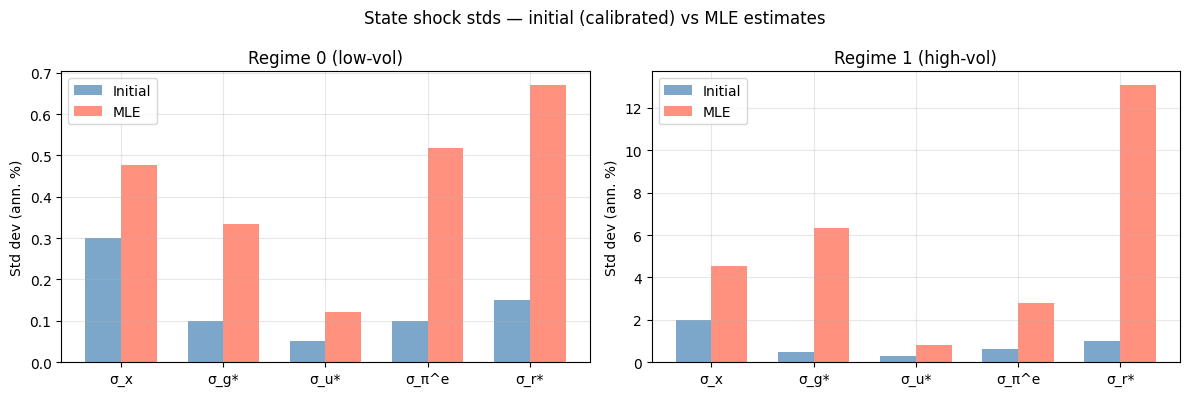

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
state_labels = ["σ_x", "σ_g*", "σ_u*", "σ_π^e", "σ_r*"]
x = np.arange(5)
w = 0.35

for k, (ax, label) in enumerate(zip(axes, ["Regime 0 (low-vol)", "Regime 1 (high-vol)"])):
    ax.bar(x - w/2, params.state_sigmas[k],     w, label="Initial",  color="steelblue", alpha=0.7)
    ax.bar(x + w/2, params_hat.state_sigmas[k], w, label="MLE",      color="tomato",    alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(state_labels)
    ax.set_title(label)
    ax.set_ylabel("Std dev (ann. %)")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("State shock stds — initial (calibrated) vs MLE estimates")
plt.tight_layout()

## 6  Filter FRED Data

Run the Kim (1994) approximate filter on the actual FRED observations
using the MLE-estimated model.

In [46]:
y = df[["gdp_growth", "unemployment", "inflation", "ffr"]].to_numpy()
filt = kim_filter(model_hat, y)
print(f"Log-likelihood on FRED data: {filt.loglik:.1f}")

Log-likelihood on FRED data: -1634.4


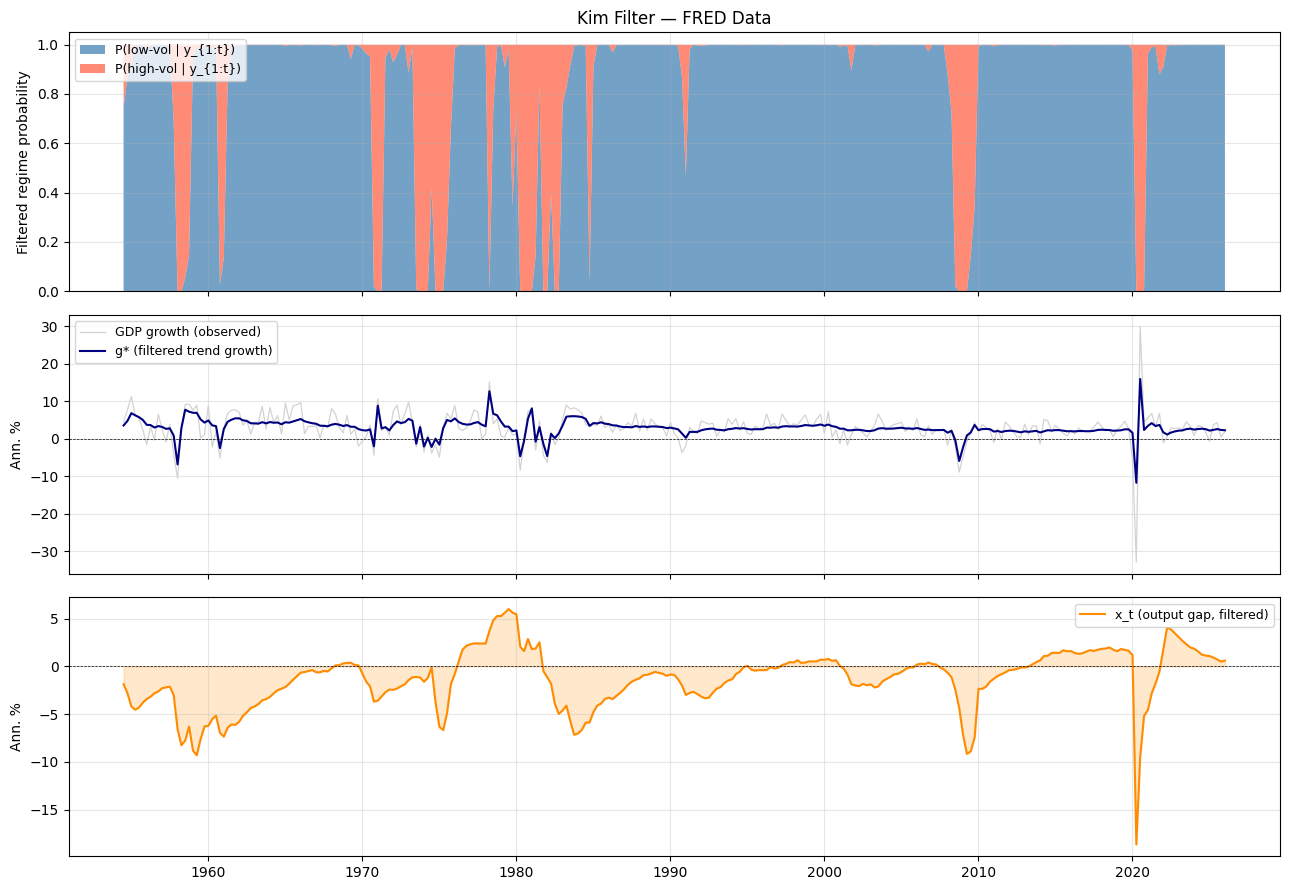

In [47]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# --- Filtered regime probabilities ---
ax = axes[0]
ax.stackplot(
    df.index,
    filt.regime_probs[:, 0],
    filt.regime_probs[:, 1],
    labels=["P(low-vol | y_{1:t})", "P(high-vol | y_{1:t})"],
    colors=["steelblue", "tomato"],
    alpha=0.75,
)
ax.set_ylabel("Filtered regime probability")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)

# --- GDP growth vs filtered trend growth g* ---
ax = axes[1]
ax.plot(df.index, df["gdp_growth"], color="lightgray", linewidth=0.9, label="GDP growth (observed)")
ax.plot(df.index, filt.state_mean[:, 1], color="navy", linewidth=1.5, label="g* (filtered trend growth)")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_ylabel("Ann. %")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Filtered output gap ---
ax = axes[2]
ax.plot(df.index, filt.state_mean[:, 0], color="darkorange", linewidth=1.5, label="x_t (output gap, filtered)")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.fill_between(df.index, filt.state_mean[:, 0], alpha=0.2, color="darkorange")
ax.set_ylabel("Ann. %")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

axes[0].set_title("Kim Filter — FRED Data")
plt.tight_layout()

## 7  Smoother

The Kim backward smoother uses the full sample $y_{1:T}$ to revise the
regime probabilities and latent-state estimates at each quarter.

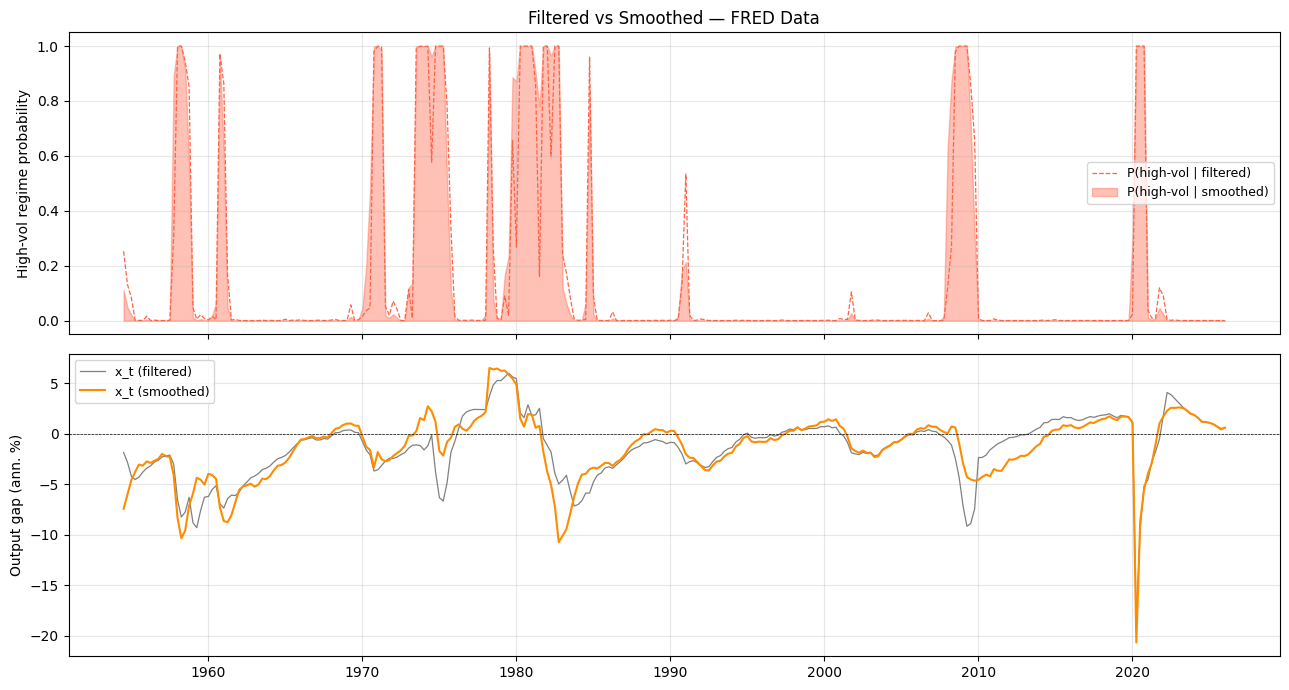

In [48]:
smooth = kim_smoother(model_hat, filt)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Filtered vs smoothed high-vol probability
ax = axes[0]
ax.plot(
    df.index, filt.regime_probs[:, 1],
    color="tomato", linewidth=0.9, linestyle="--",
    label="P(high-vol | filtered)",
)
ax.fill_between(
    df.index, smooth.smoothed_regime_probs[:, 1],
    alpha=0.4, color="tomato",
    label="P(high-vol | smoothed)",
)
ax.set_ylabel("High-vol regime probability")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Filtered vs smoothed output gap
ax = axes[1]
ax.plot(df.index, filt.state_mean[:, 0], color="gray", linewidth=0.9, label="x_t (filtered)")
ax.plot(df.index, smooth.state_mean[:, 0], color="darkorange", linewidth=1.5, label="x_t (smoothed)")
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_ylabel("Output gap (ann. %)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

axes[0].set_title("Filtered vs Smoothed — FRED Data")
plt.tight_layout()

## 8  Forecast

12-quarter (3-year) ahead forecasts with **90 % confidence intervals**,
obtained by propagating the Kim Gaussian mixture forward and computing
mixture-moment CIs.

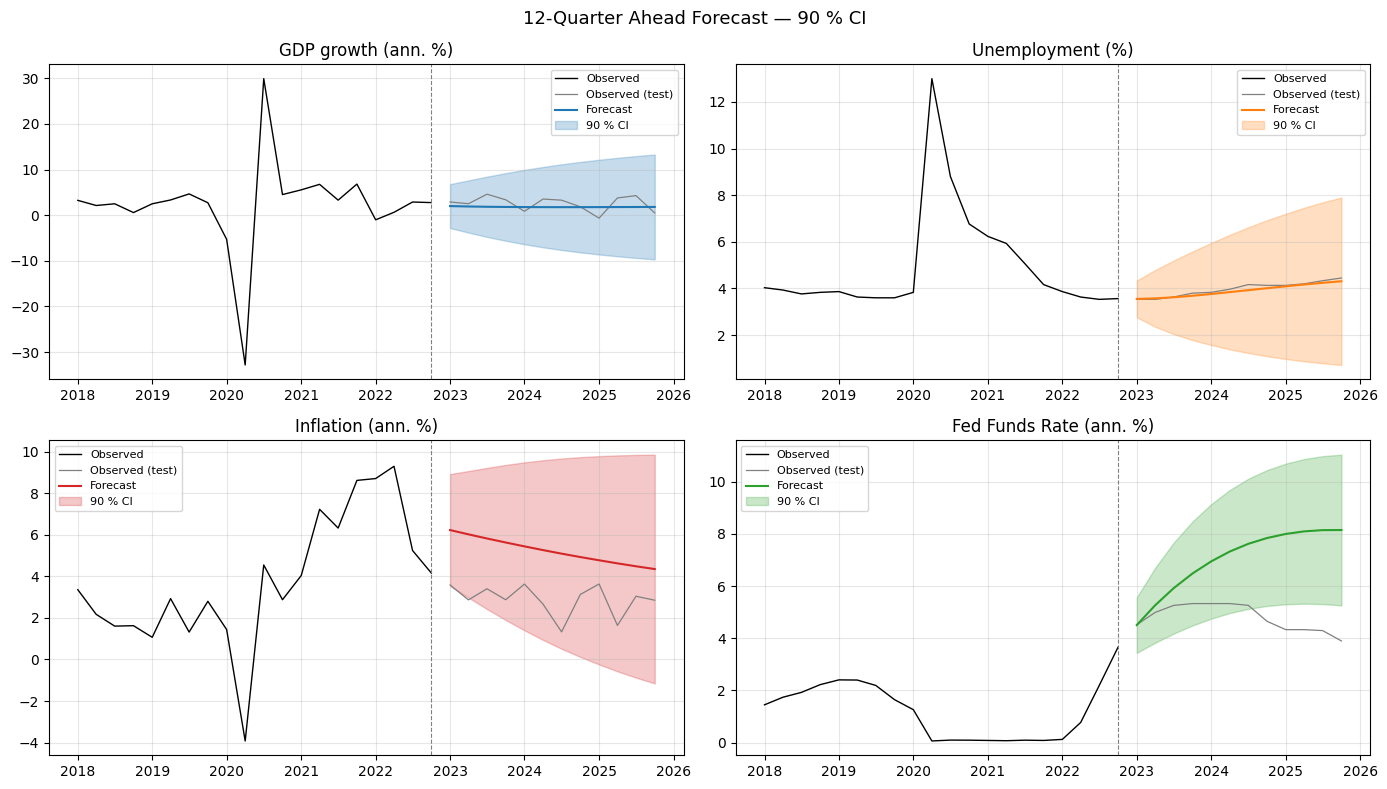

In [49]:
n_ahead = 12
y = train_df[["gdp_growth", "unemployment", "inflation", "ffr"]].to_numpy()
test_df = df[df.index > "2022-12-31"]
y_test = test_df[["gdp_growth", "unemployment", "inflation", "ffr"]].to_numpy()
filt = kim_filter(model_hat, y)
fc = forecast(model_hat, filt, y, n_ahead=n_ahead, ci_level=0.90)

last_date  = train_df.index[-1]
future_idx = pd.date_range(last_date, periods=n_ahead + 1, freq="QS")[1:]

obs_names = ["GDP growth (ann. %)", "Unemployment (%)", "Inflation (ann. %)", "Fed Funds Rate (ann. %)"]
colors    = ["tab:blue", "tab:orange", "tab:red", "tab:green"]
history   = 20  # quarters of history to show

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, name, color in zip(axes.flat, range(4), obs_names, colors):
    ax.plot(train_df.index[-history:], y[-history:, col],
            color="black", linewidth=1.0, label="Observed")
    ax.plot(test_df.index[:n_ahead], y_test[:n_ahead, col],
            color="gray", linewidth=0.9, label="Observed (test)")
    ax.plot(future_idx, fc.obs_mean[:, col],
            color=color, linewidth=1.5, label="Forecast")
    ax.fill_between(
        future_idx, fc.obs_lower[:, col], fc.obs_upper[:, col],
        color=color, alpha=0.25, label="90 % CI",
    )
    ax.axvline(last_date, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(f"{n_ahead}-Quarter Ahead Forecast — 90 % CI", fontsize=13)
plt.tight_layout()

## 9  Forecast Regime Probabilities

The `forecast` function also returns the predicted regime probabilities at
each horizon, reflecting regime uncertainty propagating forward.

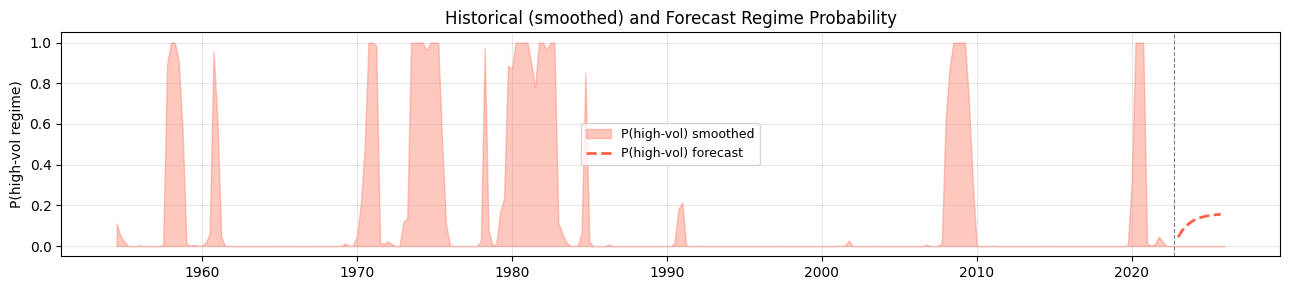

In [50]:
fig, ax = plt.subplots(figsize=(13, 3))

# Historical smoothed
ax.fill_between(
    df.index, smooth.smoothed_regime_probs[:, 1],
    alpha=0.35, color="tomato", label="P(high-vol) smoothed",
)

# Forecast
ax.plot(
    future_idx, fc.regime_probs[:, 1],
    color="tomato", linewidth=2.0, linestyle="--", label="P(high-vol) forecast",
)
ax.axvline(last_date, color="gray", linewidth=0.8, linestyle="--")
ax.set_ylabel("P(high-vol regime)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_title("Historical (smoothed) and Forecast Regime Probability")
plt.tight_layout()